In [17]:
# Olivier Dadoun Customized Lutz's notebook 
# May 2025
# S2 map analysis from MC simulation 
# Bernard Andrieu & Olivier Dadoun 

In [1]:
import os, sys
sys.path.insert(0, 'S2mapcreation/lib/python3.13/site-packages')

In [4]:
import os
import math
import zstd
import time
import pickle
from textwrap import dedent
from datetime import datetime

import multihist
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [8]:
def returns2patterns(s2map):
    # Added one extra bin around the TPC so that the outer TPC edges are exactly on the bin edge
    
    tpc_radius = 664 # on average
    xy_dimensions=[('xp_pri_rot', np.linspace((-imax)*delta_x/10, (imax)*delta_x/10, 2*imax+1)), #np.linspace((-imax+1/2)*delta_x/10, (imax-1/2)*delta_x/10, 2*imax)),
                    ('yp_pri_rot', np.linspace((-jmax-1/2)*delta_y/10, (jmax+1/2)*delta_y/10, 2*jmax+2)), #np.linspace(-jmax*delta_y, jmax*delta_y, 2*jmax+1)),
                    # store not detected events in PMTID -1
                    ('pmthitID', np.arange(-0.5, 494+0.5))]
    
    s2patterns = multihist.Histdd(dimensions=xy_dimensions)
    k=0
    for i in range(-imax,imax):
        x = (i + 1./2.) * delta_x
        for j in range(-jmax,jmax+1):
            y = j * delta_y
            if x*x + y*y < Rtpc*Rtpc:
                s2patterns.histogram[i+imax][j+jmax] = s2map.T[k].to_list()
                k+=1
    return s2patterns           

In [9]:
def write_to_straxenfile(hist, filename, directory, map_description, map_name, quantum=0.0001):
    LCE_pmt = hist.similar_blank_histogram()
    LCE_pmt[:,:] = hist[:,:]/100

    bin_centers_x = LCE_pmt.bin_centers('xp_pri_rot')
    bin_centers_y = LCE_pmt.bin_centers('yp_pri_rot')
    #bin_halfwidth_x = (bin_centers_x.max() - bin_centers_x.min())/(len(bin_centers_x) - 1)/2
    
    coordinate_system=[['x', (bin_centers_x.min(), bin_centers_x.max(), len(bin_centers_x))],
                        ['y', (bin_centers_y.min(), bin_centers_y.max(), len(bin_centers_y))],]

    # To fit the large XENONnT per-PMT MC maps into strax_auxiliary files, I quantized them to values of 1e-5. 
    # That is, I store the maps as 16-bit integer multiples of 1e-5, instead of 64-bit floats. I also changed 
    # the compression of the maps to zstd instead of gzip, to improve the loading speed.
    mp = LCE_pmt.histogram#.filled(0)[:, :, :]
    dtype = np.uint16
    encode_until = np.iinfo(dtype).max * quantum
    if mp.max() > encode_until:
        raise ValueError(f"Map maximum value is {mp.max():.4f}, can encode values until {encode_until:.4f}")

    # Output the per-PMT LCE map
    output = dict(coordinate_system=coordinate_system,
                  rotated=True,
                  description=dedent(map_description),
                  timestamp=time.time(),
                  name=map_name,
                  quantized=quantum,
                  compressed=('zstd', dtype, mp.shape),
                  map=zstd.compress(np.round(mp / quantum).astype(dtype)))

    fn = os.path.join(directory, filename + ".pkl")
    with open(fn, mode='wb') as f:
        pickle.dump(output, f)
    print(f"Wrote new map file {fn}, {os.path.getsize(fn)/1e6:.2f} MB")

In [10]:
# TPC dimensions and map binning in mm
Rtpc=664.
Reff=664.
delta_x=10.
delta_y=5.
imax = int(np.ceil(Rtpc/delta_x))
jmax = int(np.ceil((Rtpc/delta_y)-(1./2.)))

colnames=list(range(494))
s2map = pd.read_csv('S2map_txt.csv', 
                    sep=';', names=colnames, comment='#', index_col=False)

s2patterns = returns2patterns(s2map)
namepkl='XENONnT_S2_xy_patterns_LCE_MCvUNKNOWN_wires_realistic'
write_to_straxenfile(s2patterns, namepkl, "./", 
                     f"XENONnT S2 LCE per-PMT map, no PMT efficiencies, plain LCE (Lutz Althüser, {datetime.now().strftime('%d %B %Y')})", 
                     'XENONnT S2 LCE per-PMT map', quantum=0.00001)

Wrote new map file ./XENONnT_S2_xy_patterns_LCE_MCvUNKNOWN_wires_realistic.pkl, 11.11 MB


In [11]:
def load_map(map_file):
    with open(map_file, mode='rb') as f:
        data = pickle.load(f)

    # Decompress / dequantize the map
    if 'compressed' in data:
        compressor, dtype, shape = data['compressed']
        if compressor == "zstd":
            data['map'] = np.frombuffer(zstd.decompress(data['map']), dtype=dtype).reshape(*shape)
            del data['compressed']
    if 'quantized' in data:
        data['map'] = data['quantized'] * data['map'].astype(np.float32)
        del data['quantized']

    if "rotated" in data:
        print("rotated")
    
    # Add a mask for bins without any events
    
    #data['map'] = np.ma.masked_where(condition=(data['map'] == 0), a=data['map'])

     
    hist = multihist.Histdd(dimensions=[(ax, np.linspace(left-((right - left)/(points - 1)/2), right+((right - left)/(points - 1)/2), points+1)) for ax, (left, right, points) in data['coordinate_system']] + 
                                       [('pmthitID', np.arange(-0.5, data['map'].shape[2]))])
    hist.histogram = data['map']
    return hist

rotated


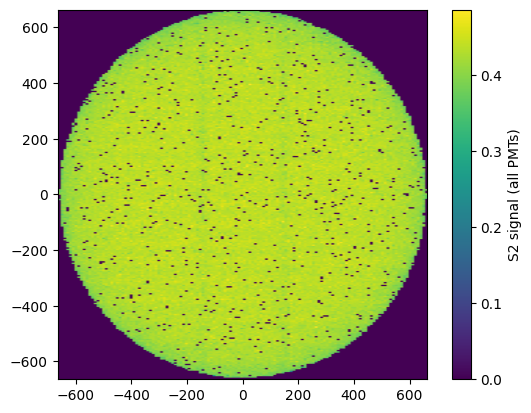

In [12]:
#map_file = "./XENONnT_S2_xy_patterns_LCE_MCvUNKNOWN_wires_realistic.pkl"
map_file = "old.pkl"
histall = load_map(map_file)
histnew=histall.histogram.sum(axis=2)
plt.imshow(histnew.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

rotated


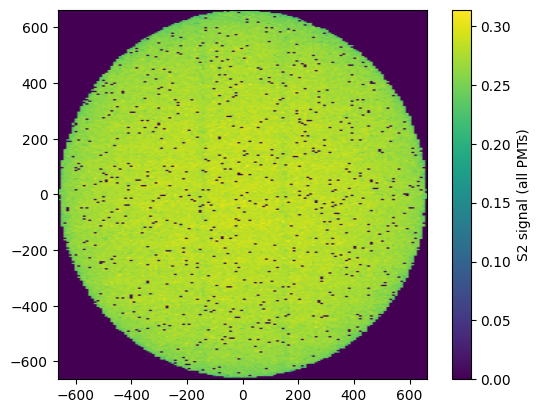

In [14]:
#map_file = "./XENONnT_S2_xy_patterns_LCE_MCvUNKNOWN_wires_realistic.pkl"
map_file = "old_QE.pkl"
histall = load_map(map_file)
histnew=histall.histogram.sum(axis=2)
plt.imshow(histnew.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

rotated


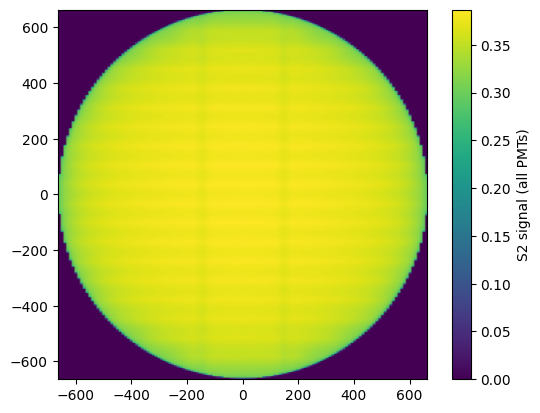

In [26]:
#map_file = "./XENONnT_S2_xy_patterns_LCE_MCvUNKNOWN_wires_realistic.pkl"
map_file = "MapNewBinning/S2map_SR0.pkl"
histall = load_map(map_file)
histnew=histall.histogram.sum(axis=2)
plt.imshow(histnew.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

rotated


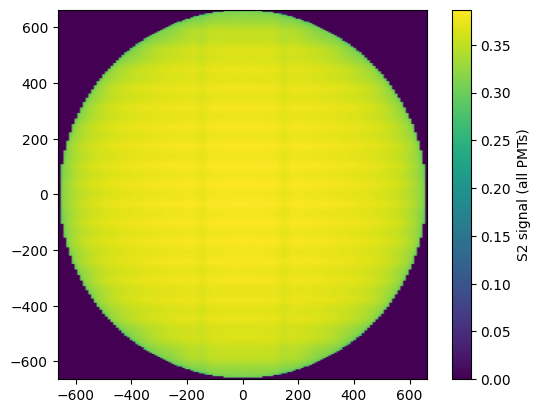

In [27]:
map_file = "MapOldBinning/S2_LCE_SR0_map.pkl"
histall = load_map(map_file)
histold =histall.histogram.sum(axis=2)
plt.imshow(histold.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

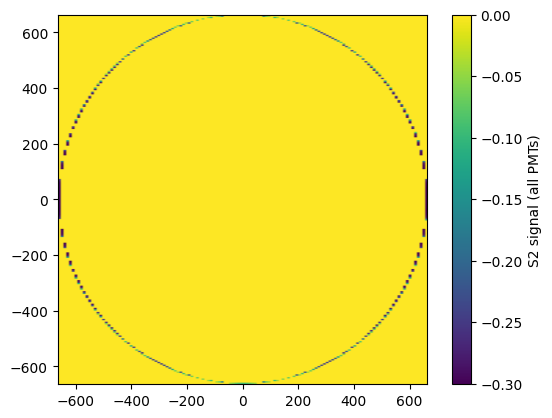

In [28]:
histdiff= histold - histnew
plt.imshow(histdiff.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

In [63]:
# Exemple de DataFrame
df = pd.DataFrame({
    "A": [1, 2, 3, 4],
    "B": ["x", "y", "z", "w"]
})

# Codes ANSI de couleur
color_codes = {
    'black': '30', 'red': '31', 'green': '32', 'yellow': '33',
    'blue': '34', 'magenta': '35', 'cyan': '36', 'white': '37',
    'default': '39',
}
bg_codes = {name: str(int(code) + 10) for name, code in color_codes.items()}

def colorize(text, text_color="white", bg_color="blue", blinking=False):
    text_code = color_codes.get(text_color, '37')
    bg_code = bg_codes.get(bg_color, '40')
    start = f"\033[5;{text_code};{bg_code}m" if blinking else f"\033[{text_code};{bg_code}m"
    reset = "\033[0m"
    return f"{start}{text}{reset}"

# Afficher le DF avec une ligne sur deux colorée
lines = df.to_string(index=False).split("\n")
for i, line in enumerate(lines):
    if i % 2 == 0:
        print(colorize(line, text_color="black", bg_color="yellow"))
    else:
        print(line)

 A B
 1 x
 2 y
 3 z
 4 w


In [1]:
A='toto'
B='BABA'
print(B+A)

BABAtoto


rotated


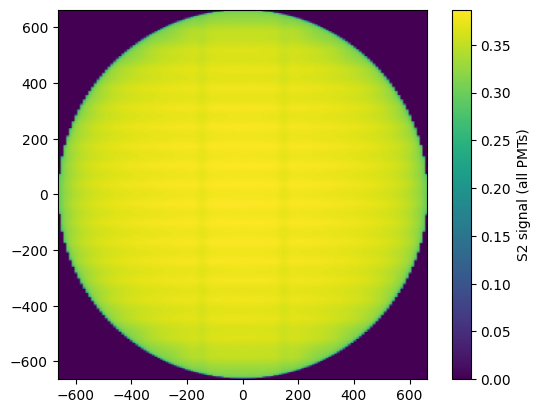

In [50]:
map_file = "S2patternMerged.pkl"
histall = load_map(map_file)
hist =histall.histogram.sum(axis=2)
plt.imshow(hist.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")


rotated


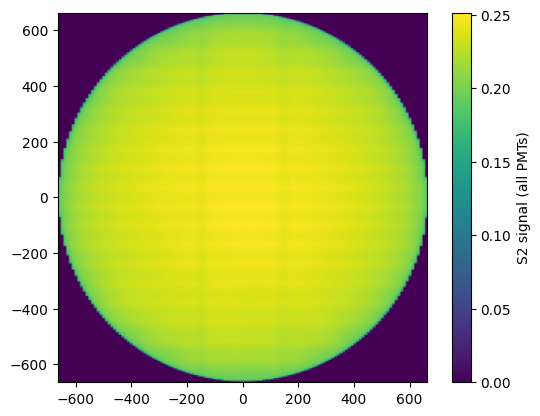

In [55]:
map_file = "S2patternMergedQE.pkl"
histall = load_map(map_file)
hist_qe =histall.histogram.sum(axis=2)
plt.imshow(hist_qe.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

In [57]:
(0.35-0.25)/0.35

0.28571428571428564

rotated
rotated


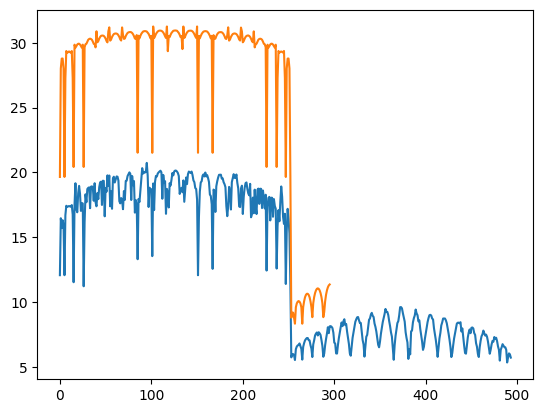

In [56]:
plt.figure()
map_file = "S2patternMerged.pkl"
histall = load_map(map_file)
hist1d = histall.histogram.sum(axis=(0, 1))


map_file = "S2patternMergedQE.pkl"
histall = load_map(map_file)
hist1d_QE = histall.histogram.sum(axis=(0, 1))
#plt.plot(hist1d[:296],label="No QE") 
plt.plot(hist1d_QE,label="No QE")
plt.plot(hist1d[:296],label="No QE") 

/var/folders/yz/546bpd_54_qf_5x9rq6c7rv80000gn/T/ipykernel_27409/1625775207.py:1: RuntimeWarning: invalid value encountered in divide
  histdiff= hist / hist_qe


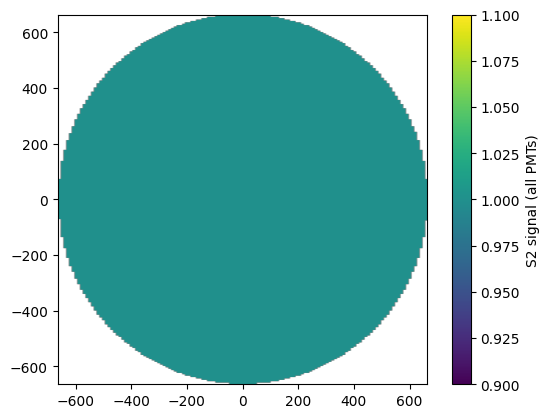

In [24]:
histdiff= hist - hist_qe
plt.imshow(histdiff.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (all PMTs)")

In [ ]:
top_slice = slice(0, 252)  
hist_top = histall.histogram[:, :, top_slice].sum(axis=2)
plt.imshow(hist_top.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
plt.colorbar(label="S2 signal (top PMTs)")

In [36]:
jmax=12
y_u = (np.arange(-jmax, jmax+1) - 0.5) * delta_y
print(y_u)
for j in range(-jmax,jmax+1): 
       y_d = (j - 1./2.) * delta_y;
       y_u = (j + 1./2.) * delta_y;
       print(y_d)

[-62.5 -57.5 -52.5 -47.5 -42.5 -37.5 -32.5 -27.5 -22.5 -17.5 -12.5  -7.5
  -2.5   2.5   7.5  12.5  17.5  22.5  27.5  32.5  37.5  42.5  47.5  52.5
  57.5]
-62.5
-57.5
-52.5
-47.5
-42.5
-37.5
-32.5
-27.5
-22.5
-17.5
-12.5
-7.5
-2.5
2.5
7.5
12.5
17.5
22.5
27.5
32.5
37.5
42.5
47.5
52.5
57.5


In [ ]:
print(hist_top.shape)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.true_divide(hist_top,hist)
    ratio[~np.isfinite(ratio)] = 0  # remplace les inf/nan par 0


plt.imshow(ratio.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='coolwarm')
plt.colorbar(label="Bottom / Top ratio")
plt.title("Top PMT /All PMT Ratio")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.show()


In [ ]:
import matplotlib.gridspec as gridspec

totpmts=494
lastoppmt=252

map_file = "./XENONnT_S2_xy_patterns_LCE_MCvUNKNOWN_wires_realistic.pkl"
histall = load_map(map_file)
hist=histall.histogram.sum(axis=2)


fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[0.05, 2, 1], wspace=0.3)

# Grand subplot à gauche (colonne 1, lignes 0 et 1)
ax1 = fig.add_subplot(gs[:, 1])
im1 = ax1.imshow(hist.T, extent=[-Rtpc,Rtpc,-Rtpc,Rtpc],cmap='viridis')
ax1.set_title("Total PMT hits")

# Colorbar du grand plot à gauche
cax1 = fig.add_subplot(gs[:, 0])
fig.colorbar(im1, cax=cax1)
cax1.yaxis.set_ticks_position('left')

# Petit subplot en haut à droite
ax2 = fig.add_subplot(gs[0, 2])
top_slice = slice(0, 252)  
hist_top = histall.histogram[:, :, top_slice].sum(axis=2)
plt.imshow(hist_top.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')

im2 = ax2.imshow(hist_top.T, extent=[-Rtpc,Rtpc,-Rtpc,Rtpc],cmap='viridis')
ax2.set_title("Top PMT hits")

# Petit subplot en bas à droite
ax3 = fig.add_subplot(gs[1, 2])
bottom_slice = slice(lastoppmt,)  
hist_bottom = histall.histogram[:, :, bottom_slice].sum(axis=2)
im3 = ax3.imshow(hist_bottom.T, extent=[-Rtpc,Rtpc,-Rtpc,Rtpc], cmap='viridis')
ax3.set_title("Bottom PMT hits")

# Colorbar pour les deux petits plots à droite
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])  # [left, bottom, width, height] en fraction de figure
fig.colorbar(im2, cax=cbar_ax)  # Suppose que im2 et im3 ont la même échelle

#plt.tight_layout(rect=[0.05, 0.05, 0.9, 0.95])
#plt.savefig('/pbs/throng/xenon/dadoun/mc/Analysis/combined.png')  # Sauvegarde en PNG
#plt.close()


In [ ]:
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.true_divide(hist_top,hist2Dall)
    ratio[~np.isfinite(ratio)] = 0  # remplace les inf/nan par 0


plt.imshow(ratio.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='coolwarm')
plt.colorbar(label="Bottom / Top ratio")
plt.title("PMT Bottom/Top Ratio")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.show()


In [ ]:
map_file = "./myPKLall.pkl"
hist = load_map(map_file)
hist2Dall = hist.histogram.sum(axis=2)

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[0.05, 2, 1], wspace=0.3)

# Grand subplot à gauche (colonne 1, lignes 0 et 1)
ax1 = fig.add_subplot(gs[:, 1])
im1 = ax1.imshow(hist2Dall.T, extent=[-Rtpc,Rtpc,-Rtpc,Rtpc],cmap='viridis')
ax1.set_title("Total PMT hits")

map_file = "./myPKLbottom.pkl"
hist = load_map(map_file)
hist2Dtop = hist.histogram.sum(axis=2)
# Colorbar du grand plot à gauche
cax1 = fig.add_subplot(gs[:, 0])
fig.colorbar(im1, cax=cax1)
cax1.yaxis.set_ticks_position('left')
cax1.yaxis.set_label_position('left')

# Petit subplot en haut à droite
ax2 = fig.add_subplot(gs[0, 2])
im2 = ax2.imshow(hist2Dtop.T, extent=[-Rtpc,Rtpc,-Rtpc,Rtpc],cmap='viridis')
ax2.set_title("Top PMT hits")

map_file = "./myPKLtop.pkl"
hist = load_map(map_file)
hist2Dbottom = hist.histogram.sum(axis=2)
# Petit subplot en bas à droite
ax3 = fig.add_subplot(gs[1, 2])
im3 = ax3.imshow(hist2Dbottom.T, extent=[-Rtpc,Rtpc,-Rtpc,Rtpc], cmap='viridis')
ax3.set_title("Bottom PMT hits")

# Colorbar pour les deux petits plots à droite
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])  # [left, bottom, width, height] en fraction de figure
fig.colorbar(im2, cax=cbar_ax)  # Suppose que im2 et im3 ont la même échelle

plt.tight_layout(rect=[0.05, 0.05, 0.9, 0.95])